**Dataset**
labeled datasset collected from Spotify (Assignment 1 - Spotify Reviews Rating)

**Objective**
classify Review to a category from 1 to 5. <br>

**Total Estimated Time = 90-120 Mins**

**Evaluation metric**
macro f1 score

### Import used libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import contractions
import matplotlib.pyplot as plt
import seaborn as sns

import spacy

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from wordcloud import WordCloud
from collections import Counter
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import (Input, Reshape, Conv2D, MaxPooling2D,
                                     Flatten, Dense, Dropout, LSTM, concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt_tab")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

2026-04-03 20:22:25.150602: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-03 20:22:25.502476: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-03 20:22:26.597670: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/o

### Load Dataset

In [2]:
df = pd.read_csv("Lab 2 - Spotify Reviews Rating.csv")
df.head(100)

,Time_submitted,Review,Rating
0,7/9/2022 15:00,"Great music service, the audio is high quality...",5
1,7/9/2022 14:21,Please ignore previous negative rating. This a...,5
2,7/9/2022 13:27,"This pop-up ""Get the best Spotify experience o...",4
3,7/9/2022 13:26,Really buggy and terrible to use as of recently,1
4,7/9/2022 13:20,Dear Spotify why do I get songs that I didn't ...,1
5,7/9/2022 13:20,The player controls sometimes disappear for no...,3
6,7/9/2022 13:19,I love the selection and the lyrics are provid...,5
7,7/9/2022 13:17,Still extremely slow when changing storage to ...,3
8,7/9/2022 13:16,It's a great app and the best mp3 music app I ...,5
9,7/9/2022 13:11,"I'm deleting this app, for the following reaso...",1


### Data splitting

It is a good practice to split the data before EDA helps maintain the integrity of the machine learning process, prevents data leakage, simulates real-world scenarios more accurately, and ensures reliable model performance evaluation on unseen data.

In [3]:
X = df['Review']
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (49275,)
X_test shape: (12319,)
y_train shape: (49275,)
y_test shape: (12319,)


**Observation:**
- The dataset is split into 80% training and 20% testing using stratified sampling to preserve the class distribution.
- Stratification ensures that each rating class (1–5) is proportionally represented in both sets, which is important for imbalanced datasets.

### EDA on training data

- check NaNs

In [4]:
print("NAN values in X_train:", X_train.isnull().sum())
print("NAN values in y_train:", y_train.isnull().sum())

NAN values in X_train: 0
NAN values in y_train: 0


**Observation:**
- No missing values found in either X_train or y_train, so no imputation or row removal is needed.

- check duplicates

In [5]:
print("Number of duplicate reviews in X_train:", X_train.duplicated().sum())
print("-" * 50)
print("Duplicate examples in X_train and y_train:")
duplicates = X_train[X_train.duplicated(keep=False)]
print(pd.concat([duplicates, y_train[duplicates.index]], axis=1).head(10))
print("-" * 50)
X_train = X_train.drop_duplicates()
y_train = y_train[X_train.index]
print("After dropping duplicates:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

Number of duplicate reviews in X_train: 177
--------------------------------------------------
Duplicate examples in X_train and y_train:
                                Review  Rating
4417   This is the best music app ever       5
21092           Great music selections       5
11852           Best music player ever       5
33936             Great app for music.       5
1940            Great music collection       5
4373              Not working properly       1
25888            Perfect, just perfect       5
10664                     Too much ads       4
16790       Good music and easy to use       5
19158          Very nice app for music       5
--------------------------------------------------
After dropping duplicates:
X_train shape: (49098,)
y_train shape: (49098,)


**Observation:**
- Duplicate reviews exist in the training set, some with different ratings.
- Duplicates are dropped to avoid biasing the model and inflating evaluation metrics.

- show a representative sample of data texts to find out required preprocessing steps

In [6]:
print("Random sample of reviews from X_train:")
print(X_train.sample(20))
print("-" * 50)

Random sample of reviews from X_train:
34740    The second most recent update made the app all...
50781    It's solid as a music service wish there were ...
41091    Been using Spotify premium for over 7 years no...
5741     Having been on spotify for as long as it's bee...
14230    I'm not able to cancel my monthly subscription...
3198             Downloaded the app but it is not opening.
23741    You think it they got it.wish spotify provide ...
19885    It's a nice app but there's a few songs that's...
3500     Cant control phone volume from GW4. Have to co...
55678    I only watch for Joe Rogan's podcast!!! He is ...
25155    When I downloaded and started the app, it was ...
30498    definitely the best app for streaming music & ...
10594    Great app but annoying when it rehularly think...
2990     Amazing streaming music app! The sound quality...
24975    Trash, it's last.fm with worse sound quality u...
42148    Overall a great app. Picked it up because I'm ...
9748     Ok it's 

In [7]:
print("Sample of reviews per rating:")
for rating in sorted(y_train.unique()):
    print(f"\nRating {rating}:")
    print(X_train[y_train == rating].sample(5))
    print("-" * 50)

Sample of reviews per rating:

Rating 1:
28226    Used to love this app but recently I haven't b...
10715    7min of music then 5min of ads Says 30min unin...
16631    Bug is detected in new vivo T1 44w Due to whic...
15662    Been using this app to play music but the rece...
46748    I pay for premium and right now it's not letti...
Name: Review, dtype: object
--------------------------------------------------

Rating 2:
19226    Great for finding alt playlists for your perso...
11978    Downloaded music won't play without an interne...
33297    It doesn't let me play all the songs I wanted ...
10794    Spotify as a service is great, I have a paid a...
51933    I have been using the app for 2 years but this...
Name: Review, dtype: object
--------------------------------------------------

Rating 3:
20038    Would it be possible to have 2.2x speed change...
5413     This is my main app for streaming music and I'...
31610    App stopped working suddenly with my cars Blue...
5217     It'

**Observation:**
- Reviews vary significantly in length, tone, and language style across ratings.
- Common patterns spotted: emojis, special characters, elongated words (e.g., "soooo"), and mixed casing.

- check dataset balancing

Number of samples in each class:
Rating
5    17570
1    14087
4     6255
2     5686
3     5500
Name: count, dtype: int64
--------------------------------------------------
Percentage of samples in each class:
Rating
5    0.357856
1    0.286916
4    0.127398
2    0.115809
3    0.112021
Name: proportion, dtype: float64


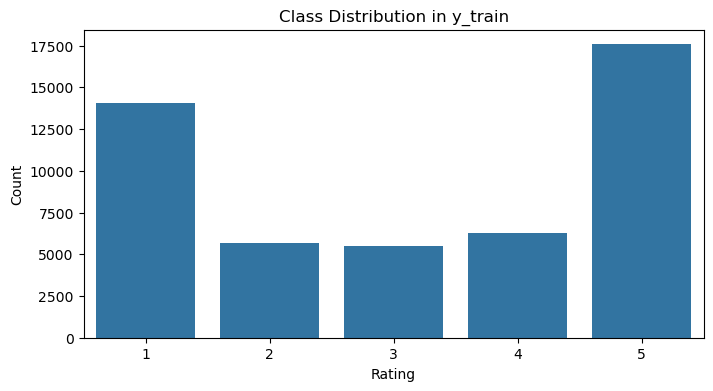

In [8]:
print("Number of samples in each class:")
print(y_train.value_counts())
print('-' * 50)
print("Percentage of samples in each class:")
print(y_train.value_counts(normalize=True))

fig = plt.figure(figsize=(8, 4))
sns.countplot(x=y_train, order=sorted(y_train.unique()))
plt.title("Class Distribution in y_train")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

- Pattern analysis on text

In [9]:
url_pattern = r'https?://\S+|www\.\S+'
print("URLs in X_train:")
try: print(X_train[X_train.str.contains(url_pattern, regex=True)].sample(10))
except: print("No URLs found or less than 10 samples.")

print('-' * 50)

special_char_pattern = r'[^\w\s]'
print("Special characters in X_train:")
print(X_train[X_train.str.contains(special_char_pattern, regex=True)].sample(10))

URLs in X_train:
No URLs found or less than 10 samples.
--------------------------------------------------
Special characters in X_train:
35940    I don't know what you did but lately half of t...
49124    Good music with ads that aren't annoying. Work...
21552    Fix your UI. This left aligned nonsense is hor...
40524    Lesson music re lesson why your disturb my min...
19738    Spotify has just completely stopped playing an...
18209             A way to see music videos would be nice.
30130    Some how i cant just tap a song in my liked pl...
58037    Player often does not work correctly and Too m...
60325    It's amazing but the watching an ad for 30 min...
16840    I just want to play song from my playlists the...
Name: Review, dtype: object


In [10]:
number_pattern = r'\d+'
print("Numbers in X_train:")
print(X_train[X_train.str.contains(number_pattern, regex=True)].sample(10))

print('-' * 50)

whitespace_pattern = r'\s{2,}'
print("Extra whitespace in X_train:")
try: print(X_train[X_train.str.contains(whitespace_pattern, regex=True)].sample(10))
except: print("No extra whitespace found or less than 10 samples.")

Numbers in X_train:
1605     I have never been happier with a music provide...
40079    If you want my money, this service should cost...
41940    It's good but when it play the ads it say you ...
56056    The longer you go without premium, the more ad...
1277     I paid last month for Premium Family & my wife...
37696    Other bug is that offline numbers, being downl...
22884    I love spotify, it's made things so much easie...
55813    The Joe Rogan Podcast is what brought me here ...
38477    Stop playing on and off on bluetooth devices. ...
23016    S22 Ultra. When this app works it is great. So...
Name: Review, dtype: object
--------------------------------------------------
Extra whitespace in X_train:
No extra whitespace found or less than 10 samples.


In [11]:
emoji_pattern = re.compile("["
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    u"\U00002702-\U000027B0"
    u"\U000024C2-\U0001F251"
    u"\U00002600-\U000026FF"
    u"\U00002700-\U000027BF"
    u"\U0000FE00-\U0000FE0F"
    u"\U0001F900-\U0001F9FF"
    "]+", flags=re.UNICODE)

print("Reviews with emojis in X_train:")
emoji_reviews = X_train[X_train.apply(lambda x: bool(emoji_pattern.search(x)))]
print(f"Count: {len(emoji_reviews)}")
print(emoji_reviews.sample(10))

Reviews with emojis in X_train:
Count: 4291
14983    I can't even access my playlist without data c...
33183    Great. Just that don't translate the lyrics. S...
16767    So good can play the music all the time I want...
51410    This app so bad. I hate your new update now be...
46513    Today my app crashed few times and surprisingl...
15560           I have no words it's just so amazing ✨ ❤ 💖
5160              Spotify is the best thing since sliced 🍞
56439    I love the fast connection to stream music and...
53333            Absolutely the best music app available ❤
20018    This New update is sooo bad i miss the old ver...
Name: Review, dtype: object


In [12]:
elongation_pattern = r'\b\w*(.)\1{2,}\w*\b'
elongated_reviews = X_train[X_train.str.contains(elongation_pattern, regex=True)]
print(f"Reviews with elongated words: {len(elongated_reviews)}")
print('-' * 50)
print(elongated_reviews.sample(10))

Reviews with elongated words: 1657
--------------------------------------------------
49428    Amazingggg I love it so much!! Premium is hone...
55566    Nothing on yt premium! Why anybody would get s...
5073     Excellent......I request the music.....it gets...
60322    Very happy with the services, i have too many ...
40643    Edit: The greed became a real issue lately...i...
21566    Really enjoy the app❤️ best app for listening ...
34890    5+ years customer, the audio quality is really...
59860    Worstttt !!! Only a premium member gets everyt...
53279    It's really good but the problem is my cousin ...
52829    I'm trying to play a specific podcast but I ca...
Name: Review, dtype: object


/tmp/ipykernel_22184/2460058093.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  elongated_reviews = X_train[X_train.str.contains(elongation_pattern, regex=True)]


- Word Cloud per rating

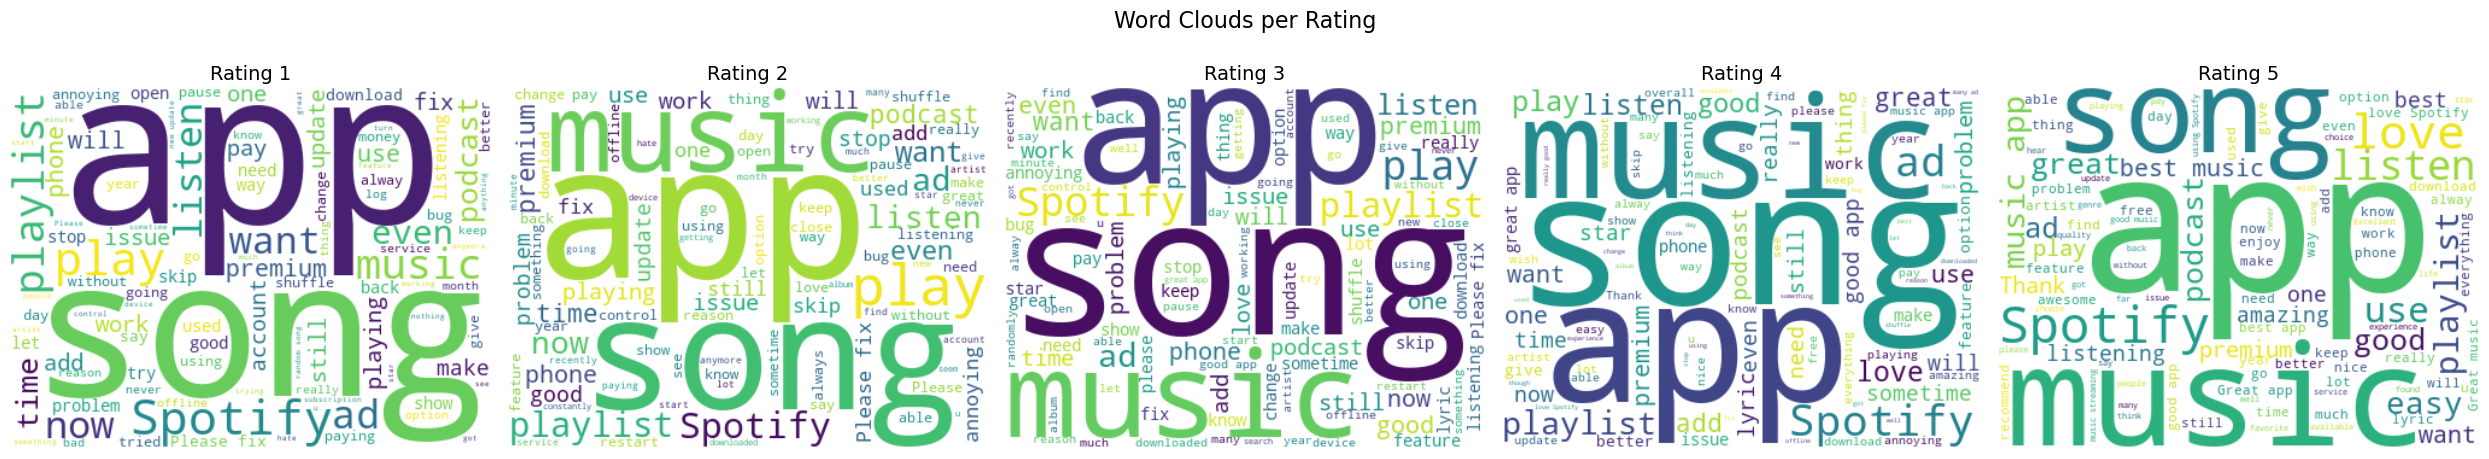

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, rating in enumerate(sorted(y_train.unique())):
    text = ' '.join(X_train[y_train == rating])
    wc = WordCloud(width=400, height=300, background_color='white', max_words=100).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Rating {rating}', fontsize=14)
    axes[i].axis('off')

plt.suptitle('Word Clouds per Rating', fontsize=16)
plt.tight_layout()
plt.show()

**Observation:**
- Common stopwords ("the", "to", "and", "I") dominate all word clouds, making it hard to distinguish between ratings.
- Low ratings (1–2) show words like "crash", "fix", "update", "bug" hinting at negative experiences.
- High ratings (4–5) show words like "love", "great", "best", "music" reflecting positive sentiment.
- Preprocessing (stopword removal, lowercasing) is needed to reveal more meaningful patterns.

- Top 20 Most Frequent Words per rating

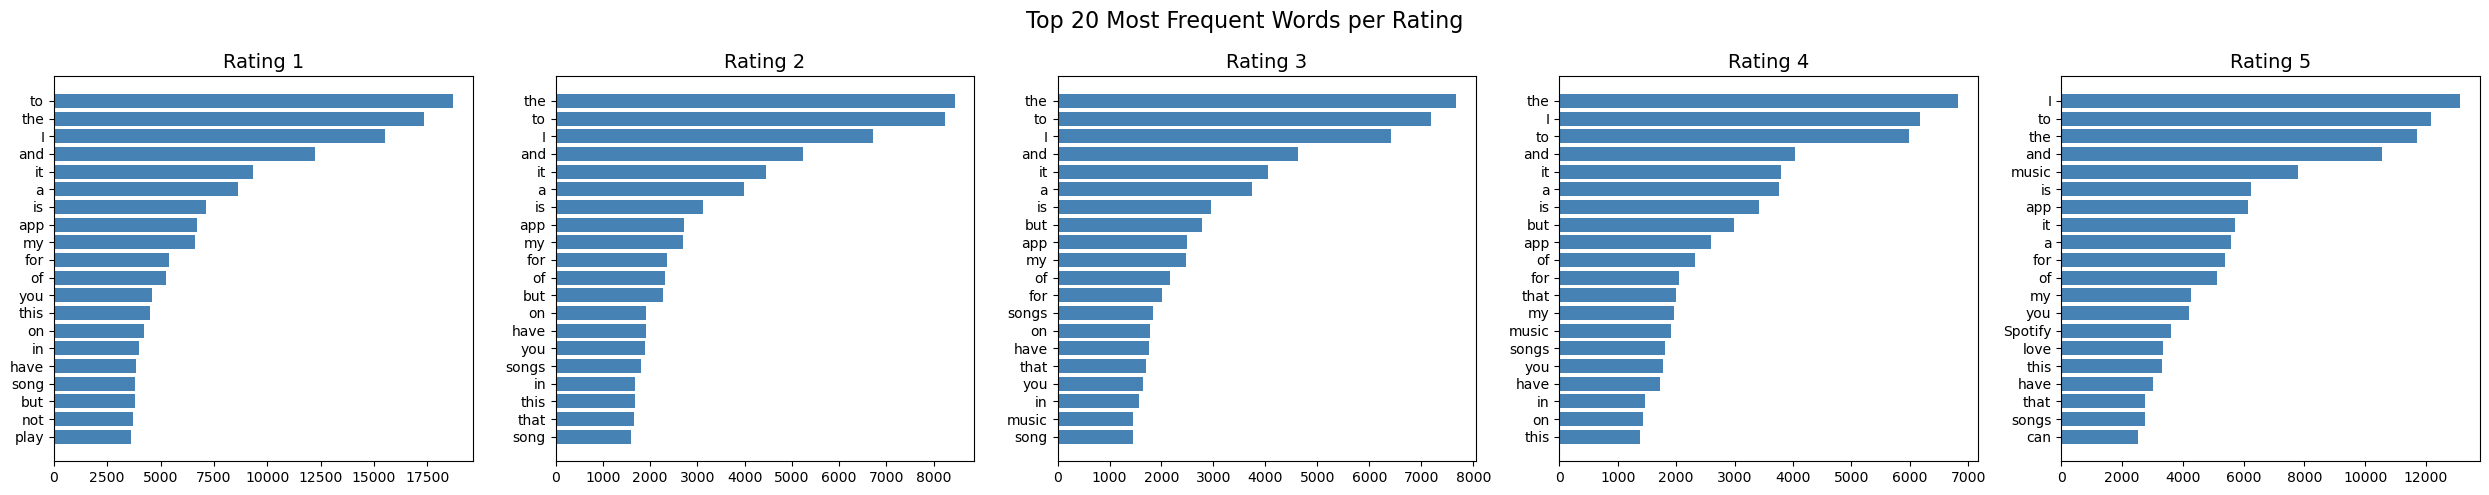

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, rating in enumerate(sorted(y_train.unique())):
    words = ' '.join(X_train[y_train == rating]).split()
    most_common = Counter(words).most_common(20)
    words_list, counts = zip(*most_common)
    axes[i].barh(range(len(words_list)), counts, color='steelblue')
    axes[i].set_yticks(range(len(words_list)))
    axes[i].set_yticklabels(words_list)
    axes[i].invert_yaxis()
    axes[i].set_title(f'Rating {rating}', fontsize=14)

plt.suptitle('Top 20 Most Frequent Words per Rating', fontsize=16)
plt.tight_layout()
plt.show()

**Observation:**
- Stopwords ("the", "I", "a", "to") are the most frequent across all ratings, confirming the need for stopword removal.
- After ignoring stopwords, negative ratings share words like "app", "update", "song" in complaint contexts, while positive ratings feature "music", "love", "good".

- Median Review Length per rating

Rating 1 — Median: 32.0, Mean: 37.1, Max: 157
Rating 2 — Median: 35.0, Mean: 39.7, Max: 159
Rating 3 — Median: 32.0, Mean: 37.0, Max: 150
Rating 4 — Median: 25.0, Mean: 30.9, Max: 222
Rating 5 — Median: 16.0, Mean: 21.5, Max: 110
--------------------------------------------------


/tmp/ipykernel_22184/3700575626.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=sorted(y_train.unique()))


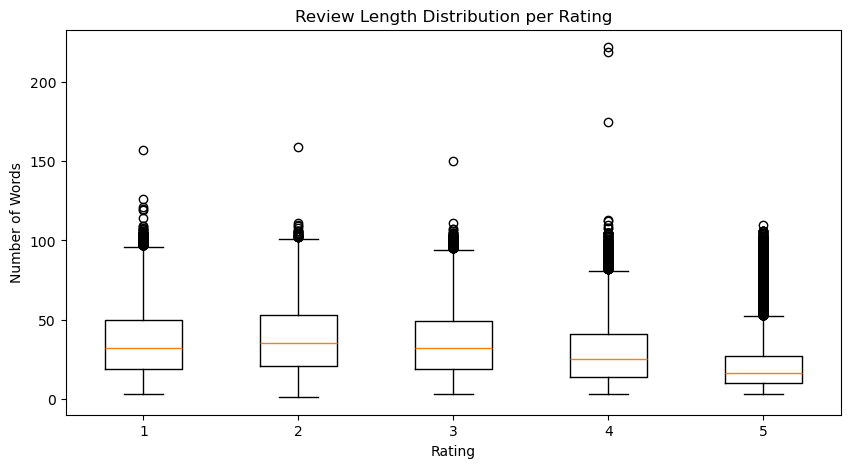

In [15]:
review_lengths = {}
for rating in sorted(y_train.unique()):
    lengths = X_train[y_train == rating].apply(lambda x: len(x.split()))
    review_lengths[rating] = lengths
    print(f"Rating {rating} — Median: {lengths.median()}, Mean: {lengths.mean():.1f}, Max: {lengths.max()}")

print('-' * 50)

fig, ax = plt.subplots(figsize=(10, 5))
data_to_plot = [review_lengths[r] for r in sorted(y_train.unique())]
ax.boxplot(data_to_plot, labels=sorted(y_train.unique()))
ax.set_title("Review Length Distribution per Rating")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Words")
plt.show()

**Observation:**
- Negative reviews (ratings 1–2) tend to be longer, as users elaborate on issues and complaints.
- Positive reviews (ratings 4–5) tend to be shorter.

- Cleaning and Preprocessing are:
    - 1. Apply Contractions
    - 2. Lowercase all text
    - 3. Remove emojis
    - 4. Reduce elongated words (e.g., "soooo" → "soo")
    - 5. Remove numbers
    - 6. Remove special characters and punctuation
    - 7. Tokenization
    - 8. Remove stopwords
    - 9. Apply lemmatization

### Cleaning and Preprocessing

In [ ]:
def clean_review(text):

    # apply contractions
    text = contractions.fix(text)

    # lowercase
    text = text.lower()

    # remove emojis
    text = emoji_pattern.sub('', text)

    # reduce elongated words
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove special characters and punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [17]:
keep_words = {'not', 'no', 'nor', 'never', 'neither', 'very', 'too',
              'so', 'really', 'but', 'however', 'only', 'just', 'more',
              'most', 'few', 'don', 'doesn', 'didn', 'won', 'wouldn',
              'shouldn', 'couldn', 'can', 'cannot', 'against'}

stop_words = set(stopwords.words('english')) - keep_words
lemmatizer = WordNetLemmatizer()

def preprocess_review(text, remove_stopwords=True):

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords (optional)
    if remove_stopwords:
        tokens = [token for token in tokens if token not in stop_words]

    # lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return ' '.join(tokens)

In [18]:
class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, remove_stopwords=True):
        self.remove_stopwords = remove_stopwords

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.apply(clean_review).apply(lambda x: preprocess_review(x, self.remove_stopwords))

In [ ]:
X_train_clean = X_train.apply(clean_review).apply(lambda x: preprocess_review(x, remove_stopwords=True))
print("Preprocessing applied to X_train (with stopword removal).")
print(X_train_clean.sample(5))

print("-" * 50)

X_test_clean = X_test.apply(clean_review).apply(lambda x: preprocess_review(x, remove_stopwords=True))
print("Preprocessing applied to X_test (with stopword removal).")
print(X_test_clean.sample(5))

Preprocessing applied to X_train (with stopword removal).
1086     worst app ever just purchased premium membersh...
60095    ok so really like app can listen pretty much e...
43173    good app really but going extremely good consi...
12834                  love spotify not know would without
12261    made watch second ad proceeded tell stop skipp...
Name: Review, dtype: object
--------------------------------------------------
Preprocessing applied to X_test (with stopword removal).
16435    best music lover like affordable plan good fea...
18050    fix app garbage water constant issue app not c...
14656                  love app but alot ad otherwise best
3230     phone remote tablet stereo excellent programmi...
35217    customer year disappointed change android musi...
Name: Review, dtype: object


**Observation:**
- The preprocessing pipeline applies contractions expansion, lowercasing, emoji removal, elongation reduction, number/punctuation removal, tokenization, stopword removal (keeping negation words like "not", "never"), and lemmatization.
- Negation and sentiment-bearing stopwords (e.g., "not", "no", "very", "but") are intentionally kept, as they carry important meaning for sentiment classification.
- A custom  class is built using sklearn's  and  to integrate preprocessing into sklearn pipelines seamlessly.

### Post-Cleaning Visualizations

- Word Cloud per rating (After Cleaning)

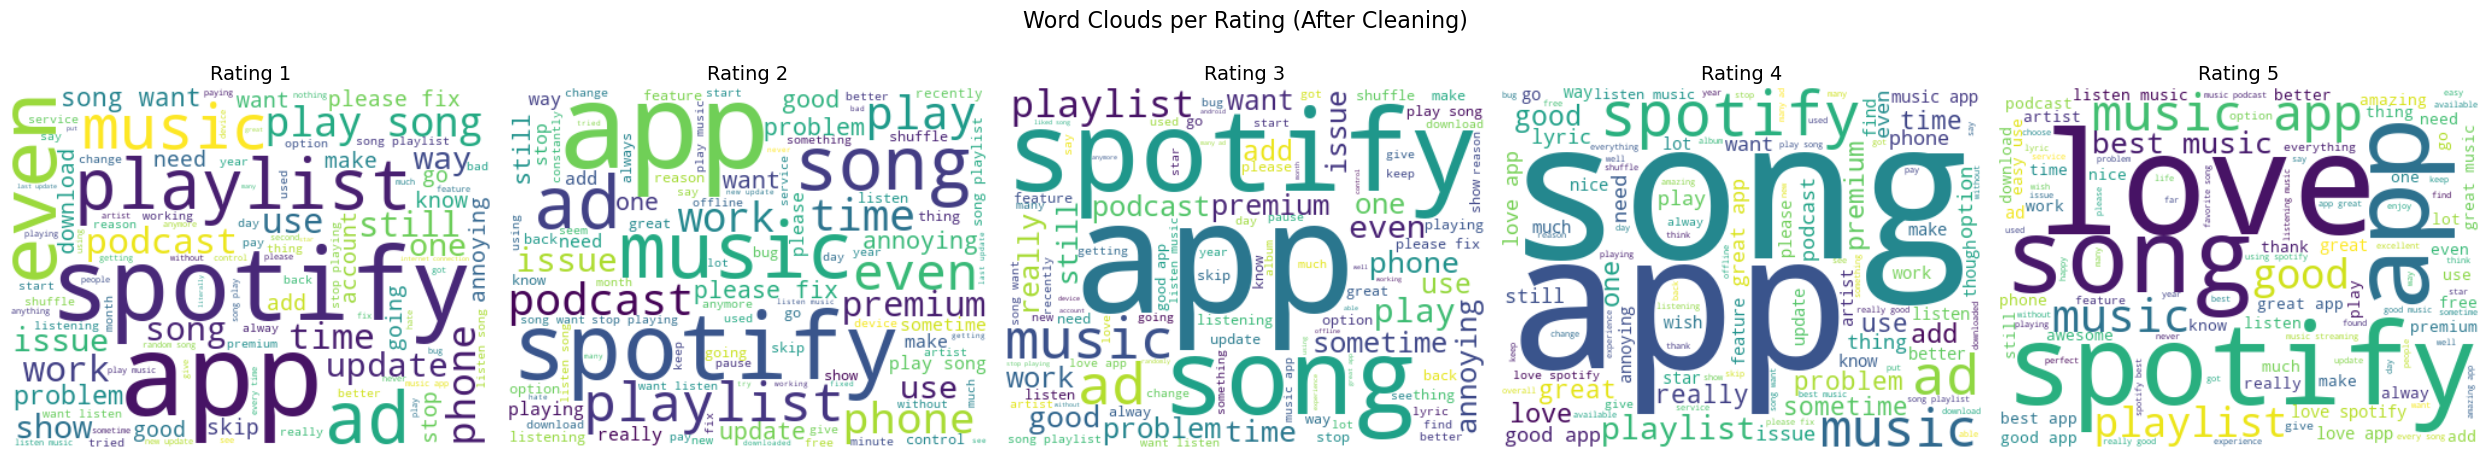

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, rating in enumerate(sorted(y_train.unique())):
    text = ' '.join(X_train_clean[y_train == rating])
    wc = WordCloud(width=400, height=300, background_color='white', max_words=100).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Rating {rating}', fontsize=14)
    axes[i].axis('off')

plt.suptitle('Word Clouds per Rating (After Cleaning)', fontsize=16)
plt.tight_layout()
plt.show()

**Observation:**
- After cleaning, word clouds now show more meaningful and distinguishing terms per rating.
- Low ratings (1–2) prominently feature words like "crash", "fix", "update", "bug", "work", reflecting user frustration.
- High ratings (4–5) highlight words like "love", "great", "music", "song", "best", reflecting satisfaction.

- Top 20 Most Frequent Words per rating (After Cleaning)

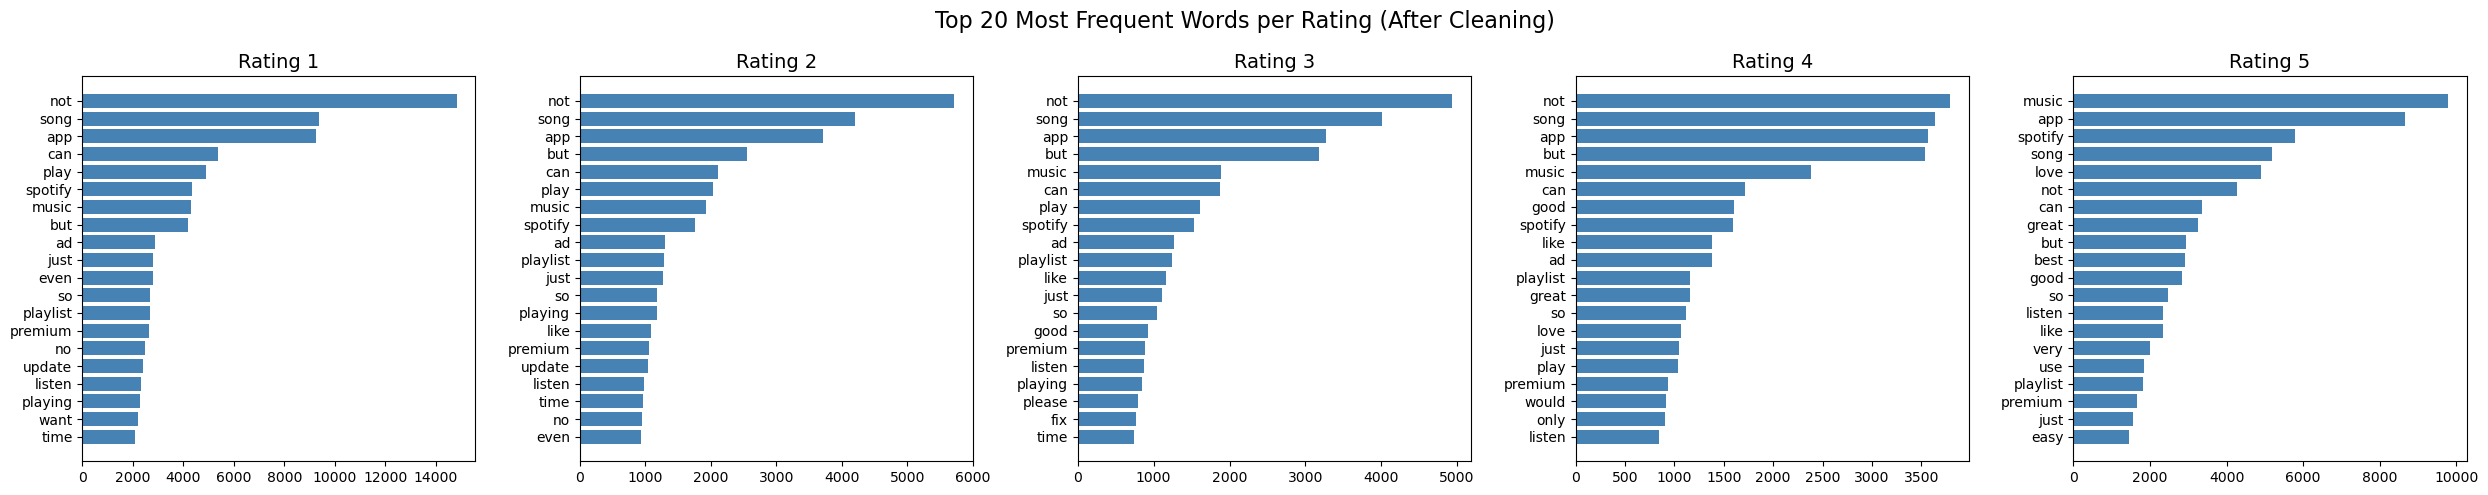

In [21]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, rating in enumerate(sorted(y_train.unique())):
    words = ' '.join(X_train_clean[y_train == rating]).split()
    most_common = Counter(words).most_common(20)
    words_list, counts = zip(*most_common)
    axes[i].barh(range(len(words_list)), counts, color='steelblue')
    axes[i].set_yticks(range(len(words_list)))
    axes[i].set_yticklabels(words_list)
    axes[i].invert_yaxis()
    axes[i].set_title(f'Rating {rating}', fontsize=14)

plt.suptitle('Top 20 Most Frequent Words per Rating (After Cleaning)', fontsize=16)
plt.tight_layout()
plt.show()

**Observation:**
- The top frequent words now clearly separate across ratings after preprocessing.
- Negative ratings are dominated by action/complaint words ("update", "fix", "crash", "work", "play").
- Positive ratings show appreciation words ("love", "great", "good", "music", "best").
- Middle rating (3) contains a mix of both, indicating ambivalent reviews.

- Median Review Length per rating (After Cleaning)

Rating 1 — Median: 18.0, Mean: 21.2, Max: 84
Rating 2 — Median: 20.0, Mean: 22.4, Max: 80
Rating 3 — Median: 18.0, Mean: 20.7, Max: 82
Rating 4 — Median: 14.0, Mean: 17.3, Max: 131
Rating 5 — Median: 9.0, Mean: 12.2, Max: 63
--------------------------------------------------


/tmp/ipykernel_22184/808915290.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=sorted(y_train.unique()))


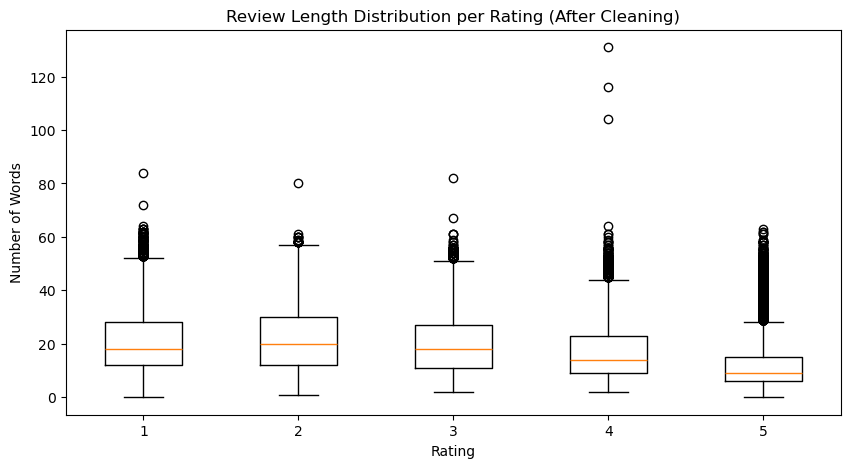

In [22]:
review_lengths_clean = {}
for rating in sorted(y_train.unique()):
    lengths = X_train_clean[y_train == rating].apply(lambda x: len(x.split()))
    review_lengths_clean[rating] = lengths
    print(f"Rating {rating} — Median: {lengths.median()}, Mean: {lengths.mean():.1f}, Max: {lengths.max()}")

print('-' * 50)

fig, ax = plt.subplots(figsize=(10, 5))
data_to_plot = [review_lengths_clean[r] for r in sorted(y_train.unique())]
ax.boxplot(data_to_plot, labels=sorted(y_train.unique()))
ax.set_title("Review Length Distribution per Rating (After Cleaning)")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Words")
plt.show()

**Observation:**
- Review lengths decreased across all ratings after cleaning due to stopword removal and preprocessing.
- The relative pattern persists: negative reviews remain longer than positive ones.

**You  are doing Great so far!**

### Modelling

In [23]:
pipeline_bow = Pipeline(steps=[
    ('preprocessing', TextPreprocessor()),
    ('vectorizing', CountVectorizer()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)),
])

param_grid_bow = {
    'vectorizing__ngram_range': [(1, 1), (1, 2), (1, 3)],
}

grid_bow = GridSearchCV(pipeline_bow, param_grid_bow, scoring='f1_macro', cv=3, verbose=1, n_jobs=-1)
grid_bow.fit(X_train, y_train)

print("Best params (BoW):", grid_bow.best_params_)
print("Best Macro F1 (BoW CV):", f"{grid_bow.best_score_:.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params (BoW): {'vectorizing__ngram_range': (1, 3)}
Best Macro F1 (BoW CV): 0.4627


In [24]:
y_pred_bow = grid_bow.predict(X_test)

#### Evaluation

**Evaluation metric:**
macro f1 score

Macro F1 score is a useful metric in scenarios where you want to evaluate the overall performance of a multi-class classification model, **particularly when the classes are imbalanced**

![Calculation](https://assets-global.website-files.com/5d7b77b063a9066d83e1209c/639c3d934e82c1195cdf3c60_macro-f1.webp)

In [25]:
f1 = f1_score(y_test, y_pred_bow, average='macro')
print(f"Macro F1 Score: {f1:.4f}")

Macro F1 Score: 0.4630


In [26]:
print("Classification Report:")
print(classification_report(y_test, y_pred_bow))

Classification Report:
              precision    recall  f1-score   support

           1       0.63      0.73      0.68      3531
           2       0.26      0.19      0.22      1424
           3       0.26      0.20      0.23      1377
           4       0.39      0.35      0.37      1568
           5       0.79      0.85      0.82      4419

    accuracy                           0.60     12319
   macro avg       0.47      0.46      0.46     12319
weighted avg       0.57      0.60      0.59     12319



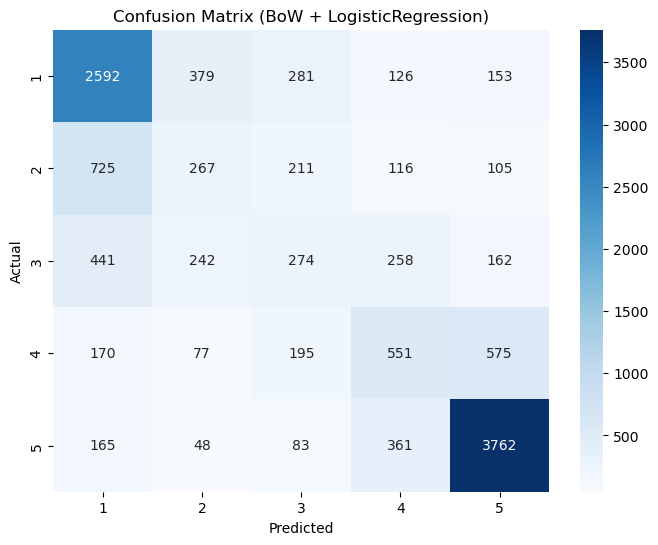

In [27]:
cm = confusion_matrix(y_test, y_pred_bow)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (BoW + LogisticRegression)')
plt.show()

**Observation:**
- The BoW + Logistic Regression baseline model uses GridSearchCV to tune n-gram ranges ((1,1), (1,2), (1,3)) with `class_weight="balanced"` to handle class imbalance.
- The confusion matrix shows the model struggles most with middle ratings (2, 3, 4), often confusing adjacent classes.
- Extreme ratings (1 and 5) are easier to classify due to more distinct language patterns.
- This serves as a solid baseline to compare against more advanced approaches.

### Enhancement

#### Enhancement 1: TF-IDF + LogisticRegression

In [28]:
pipeline_tfidf = Pipeline(steps=[
    ('preprocessing', TextPreprocessor()),
    ('vectorizing', TfidfVectorizer()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)),
])

param_grid_tfidf = {
    'vectorizing__ngram_range': [(1, 1), (1, 2), (1, 3)],
}

grid_tfidf = GridSearchCV(pipeline_tfidf, param_grid_tfidf, scoring='f1_macro', cv=3, verbose=1, n_jobs=-1)
grid_tfidf.fit(X_train, y_train)

print("Best params (TF-IDF):", grid_tfidf.best_params_)
print("Best Macro F1 (TF-IDF CV):", f"{grid_tfidf.best_score_:.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params (TF-IDF): {'vectorizing__ngram_range': (1, 3)}
Best Macro F1 (TF-IDF CV): 0.4868


In [29]:
y_pred_tfidf = grid_tfidf.predict(X_test)
print("Test Macro F1 (TF-IDF):", f"{f1_score(y_test, y_pred_tfidf, average='macro'):.4f}")

print("\nClassification Report (TF-IDF):")
print(classification_report(y_test, y_pred_tfidf))

Test Macro F1 (TF-IDF): 0.4922

Classification Report (TF-IDF):
              precision    recall  f1-score   support

           1       0.66      0.66      0.66      3531
           2       0.26      0.32      0.29      1424
           3       0.29      0.27      0.28      1377
           4       0.39      0.44      0.42      1568
           5       0.87      0.78      0.82      4419

    accuracy                           0.59     12319
   macro avg       0.49      0.49      0.49     12319
weighted avg       0.61      0.59      0.60     12319



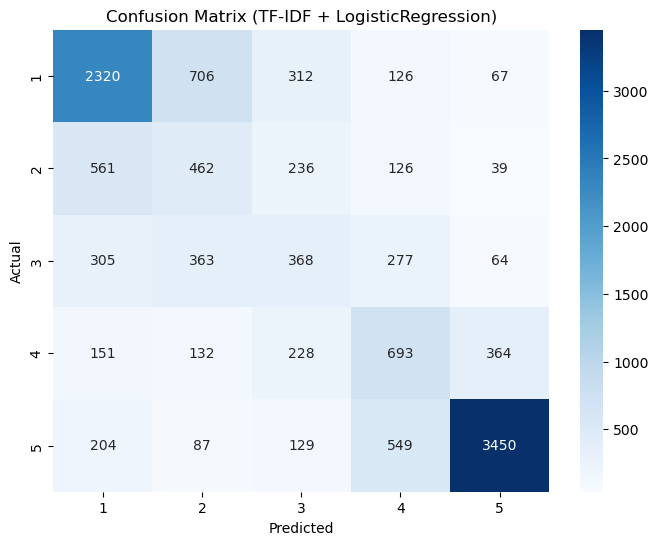

In [30]:
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (TF-IDF + LogisticRegression)')
plt.show()

**Observation:**
- TF-IDF + Logistic Regression achieved a Macro F1 of **0.4922**, improving over the BoW baseline (0.4630).
- TF-IDF weighs terms by importance (down-weighting common words, boosting rare discriminative ones), which helps the model focus on more informative features.

#### Enhancement 2: Word Embeddings (spaCy) + LinearSVC

In [31]:
nlp = spacy.load('en_core_web_md')

X_train_vectors = np.zeros((len(X_train_clean), 300))
X_test_vectors = np.zeros((len(X_test_clean), 300))

for i, doc in tqdm(enumerate(nlp.pipe(X_train_clean)), total=len(X_train_clean)):
    X_train_vectors[i, :] = doc.vector

for i, doc in tqdm(enumerate(nlp.pipe(X_test_clean)), total=len(X_test_clean)):
    X_test_vectors[i, :] = doc.vector

print("X_train_vectors shape:", X_train_vectors.shape)
print("X_test_vectors shape:", X_test_vectors.shape)

  0%|          | 0/49098 [00:00<?, ?it/s]

Exception ignored in: <function ResourceTracker.__del__ at 0x750af9198720>
Traceback (most recent call last):
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


  0%|          | 0/12319 [00:00<?, ?it/s]

Exception ignored in: <function ResourceTracker.__del__ at 0x76df0e188720>
Traceback (most recent call last):
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7b8670d90720>
Traceback (most recent call last):
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child proces

X_train_vectors shape: (49098, 300)
X_test_vectors shape: (12319, 300)


In [32]:
svc_model = LinearSVC(class_weight='balanced', random_state=42)
svc_model.fit(X_train_vectors, y_train)

y_pred_emb = svc_model.predict(X_test_vectors)
print("Test Macro F1 (Word Embeddings):", f"{f1_score(y_test, y_pred_emb, average='macro'):.4f}")

print("\nClassification Report (Word Embeddings):")
print(classification_report(y_test, y_pred_emb))

Exception ignored in: <function ResourceTracker.__del__ at 0x7a3ee1188720>
Traceback (most recent call last):
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x70070e390720>
Traceback (most recent call last):
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child proces

Test Macro F1 (Word Embeddings): 0.3808

Classification Report (Word Embeddings):
              precision    recall  f1-score   support

           1       0.52      0.67      0.58      3531
           2       0.24      0.13      0.17      1424
           3       0.23      0.12      0.16      1377
           4       0.28      0.22      0.25      1568
           5       0.70      0.80      0.75      4419

    accuracy                           0.54     12319
   macro avg       0.39      0.39      0.38     12319
weighted avg       0.49      0.54      0.50     12319



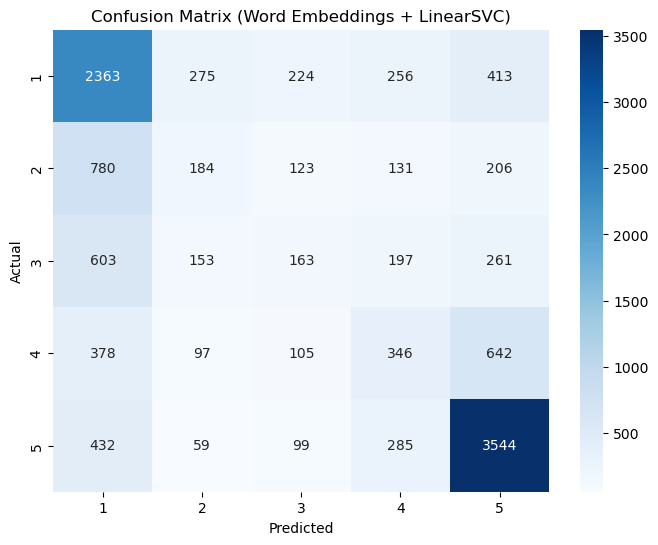

In [33]:
cm_emb = confusion_matrix(y_test, y_pred_emb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_emb, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Word Embeddings + LinearSVC)')
plt.show()

**Observation:**
- spaCy Word Embeddings + LinearSVC achieved a Macro F1 of **0.3808**, which is lower than both BoW (0.4630) and TF-IDF (0.4922).
- This is because spaCy's document-level vector averages all token embeddings into a single 300-d vector, losing word order and individual word importance.

#### Enhancement 3: CNN N-grams with Word Embeddings (spaCy)

In [34]:
def get_longest_text(texts):
    longest_input = 0
    for text in texts:
        text_len = len(text.split())
        longest_input = max(longest_input, text_len)
    return longest_input

longest_input = get_longest_text(X_train_clean)
print(f"Longest review (words): {longest_input}")

Longest review (words): 131


In [35]:
X_train_emb = np.zeros((len(X_train_clean), longest_input, 300))
X_test_emb = np.zeros((len(X_test_clean), longest_input, 300))

for i, doc in tqdm(enumerate(nlp.pipe(X_train_clean)), total=len(X_train_clean)):
    for j, token in enumerate(doc):
        if j >= longest_input:
            break
        X_train_emb[i, j] = token.vector

for i, doc in tqdm(enumerate(nlp.pipe(X_test_clean)), total=len(X_test_clean)):
    for j, token in enumerate(doc):
        if j >= longest_input:
            break
        X_test_emb[i, j] = token.vector

print("X_train_emb shape:", X_train_emb.shape)
print("X_test_emb shape:", X_test_emb.shape)

  0%|          | 0/49098 [00:00<?, ?it/s]

Exception ignored in: <function ResourceTracker.__del__ at 0x7e61f9588720>
Traceback (most recent call last):
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x76a27d980720>
Traceback (most recent call last):
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child proces

  0%|          | 0/12319 [00:00<?, ?it/s]

Exception ignored in: <function ResourceTracker.__del__ at 0x72bbe5f94720>
Traceback (most recent call last):
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


X_train_emb shape: (49098, 131, 300)
X_test_emb shape: (12319, 131, 300)


In [36]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

y_train_cat = to_categorical(y_train_encoded)
y_test_cat = to_categorical(y_test_encoded)

print("Number of classes:", len(encoder.classes_))
print("y_train_cat shape:", y_train_cat.shape)

Number of classes: 5
y_train_cat shape: (49098, 5)


In [ ]:
inputs = Input((longest_input, 300))
reshaped = Reshape((longest_input, 300, 1))(inputs)

filters = [2, 3, 4]

conv_1 = Conv2D(100, (filters[0], 300), activation='relu')(reshaped)
conv_2 = Conv2D(100, (filters[1], 300), activation='relu')(reshaped)
conv_3 = Conv2D(100, (filters[2], 300), activation='relu')(reshaped)

pool_1 = MaxPooling2D((longest_input - filters[0] + 1, 1), strides=(1,1))(conv_1)
pool_2 = MaxPooling2D((longest_input - filters[1] + 1, 1), strides=(1,1))(conv_2)
pool_3 = MaxPooling2D((longest_input - filters[2] + 1, 1), strides=(1,1))(conv_3)

merged_tensor = concatenate([pool_1, pool_2, pool_3], axis=1)

flatten = Flatten()(merged_tensor)
clf = Dense(100, activation='relu')(flatten)
clf = Dropout(0.3)(clf)
clf = Dense(len(encoder.classes_), activation='softmax')(clf)

cnn_model = Model(inputs, clf)
cnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
cnn_model.summary()

W0000 00:00:1775241073.477645   22184 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 131, 300)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 131, 300,  │          0 │ input_layer[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 130, 1,    │     60,100 │ reshape[0][0]     │
│                     │ 100)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 129, 1,    │     90,100 │ reshape[0][0]     │
│                     │ 100)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 1,    │    120,100 │ reshape[0][0]     │
│                     │ 100)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 1, 1, 100) │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 1, 1, 100) │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 1, 1, 100) │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3, 1, 100) │          0 │ max_pooling2d[0]… │
│ (Concatenate)       │                   │            │ max_pooling2d_1[… │
│                     │                   │            │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 300)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 100)       │     30,100 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 100)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        505 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 300,905 (1.15 MB)

 Trainable params: 300,905 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = cnn_model.fit(X_train_emb, y_train_cat, epochs=30, batch_size=64,
                        validation_split=0.1, callbacks=[early_stop])

Exception ignored in: <function ResourceTracker.__del__ at 0x76f6def98720>
Traceback (most recent call last):
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7e5a84798720>
Traceback (most recent call last):
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/omargamalelkady/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child proces

Epoch 1/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - acc: 0.5485 - loss: 1.1873 - val_acc: 0.5625 - val_loss: 1.1454
Epoch 2/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - acc: 0.5750 - loss: 1.1054 - val_acc: 0.5725 - val_loss: 1.1212
Epoch 3/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - acc: 0.5907 - loss: 1.0572 - val_acc: 0.5701 - val_loss: 1.1311
Epoch 4/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - acc: 0.6031 - loss: 1.0146 - val_acc: 0.5774 - val_loss: 1.1454
Epoch 5/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - acc: 0.6106 - loss: 0.9756 - val_acc: 0.5719 - val_loss: 1.1545


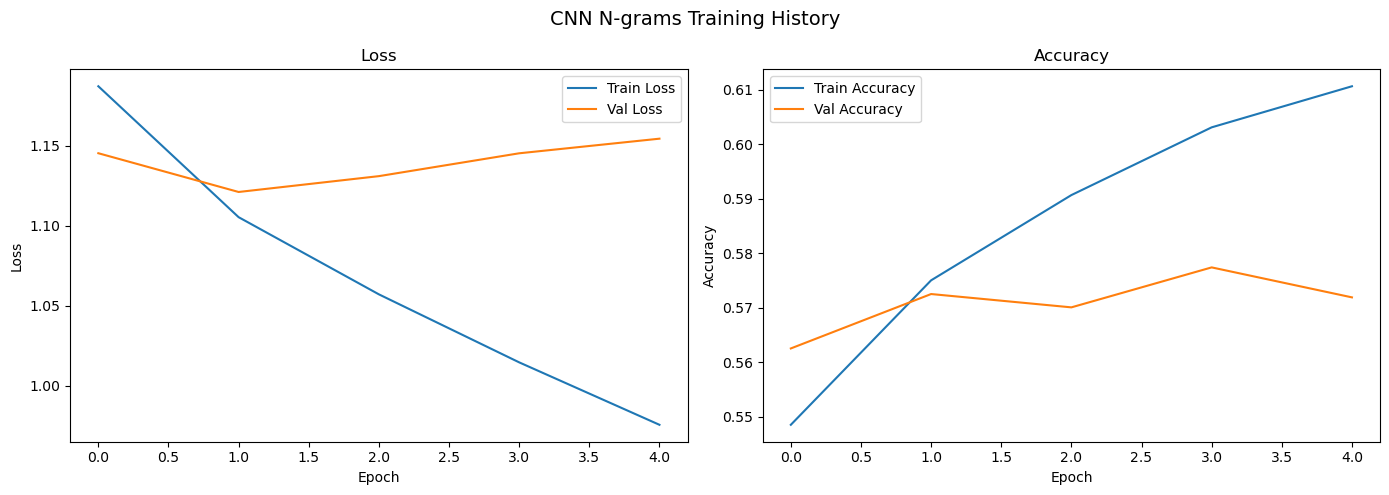

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['acc'], label='Train Accuracy')
axes[1].plot(history.history['val_acc'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('CNN N-grams Training History', fontsize=14)
plt.tight_layout()
plt.show()

In [40]:
cnn_model.evaluate(X_test_emb, y_test_cat)

385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.5762 - loss: 1.0934


[1.0933648347854614, 0.5761831402778625]

In [41]:
y_pred_cnn = encoder.inverse_transform(np.argmax(cnn_model.predict(X_test_emb), axis=1))

print("Test Macro F1 (CNN N-grams):", f"{f1_score(y_test, y_pred_cnn, average='macro'):.4f}")

print("\nClassification Report (CNN N-grams):")
print(classification_report(y_test, y_pred_cnn))

385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Test Macro F1 (CNN N-grams): 0.3196

Classification Report (CNN N-grams):
              precision    recall  f1-score   support

           1       0.48      0.89      0.62      3531
           2       0.00      0.00      0.00      1424
           3       0.21      0.00      0.01      1377
           4       0.36      0.13      0.19      1568
           5       0.72      0.85      0.78      4419

    accuracy                           0.58     12319
   macro avg       0.36      0.37      0.32     12319
weighted avg       0.47      0.58      0.48     12319



/home/omargamalelkady/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/omargamalelkady/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/omargamalelkady/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

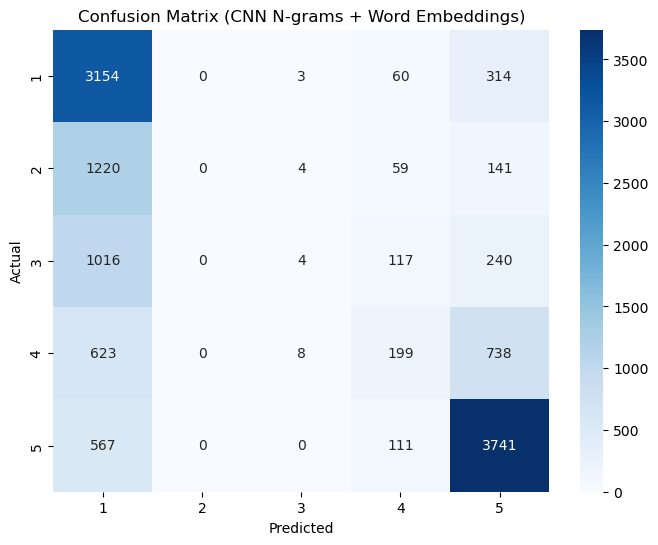

In [42]:
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (CNN N-grams + Word Embeddings)')
plt.show()

**Observation:**
- CNN N-grams achieved a Macro F1 of **0.3196**, the lowest so far among all models.
- The model heavily favors rating 1 (0.89 recall) while completely failing on ratings 2 and 3 (0.00 recall), indicating a strong bias toward the majority class, this indicates that hte model can not generalize.

#### Enhancement 4: LSTM with Word Embeddings (spaCy)

In [43]:
# define LSTM model
lstm_inputs = Input((longest_input, 300))
x = LSTM(128, return_sequences=True)(lstm_inputs)
x = Dropout(0.3)(x)
x = LSTM(64)(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
lstm_output = Dense(len(encoder.classes_), activation='softmax')(x)

lstm_model = Model(lstm_inputs, lstm_output)
lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
lstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 131, 300)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 131, 128)       │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 131, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273,541 (1.04 MB)

 Trainable params: 273,541 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_lstm = lstm_model.fit(X_train_emb, y_train_cat, epochs=30, batch_size=64,
                              validation_split=0.1, callbacks=[early_stop_lstm])

Epoch 1/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 48s 66ms/step - acc: 0.3603 - loss: 1.4876 - val_acc: 0.3460 - val_loss: 1.4876
Epoch 2/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - acc: 0.3592 - loss: 1.4846 - val_acc: 0.3460 - val_loss: 1.4878
Epoch 3/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - acc: 0.3592 - loss: 1.4839 - val_acc: 0.3460 - val_loss: 1.4869
Epoch 4/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - acc: 0.3592 - loss: 1.4840 - val_acc: 0.3460 - val_loss: 1.4876
Epoch 5/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - acc: 0.3592 - loss: 1.4835 - val_acc: 0.3460 - val_loss: 1.4881
Epoch 6/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - acc: 0.3592 - loss: 1.4834 - val_acc: 0.3460 - val_loss: 1.4872


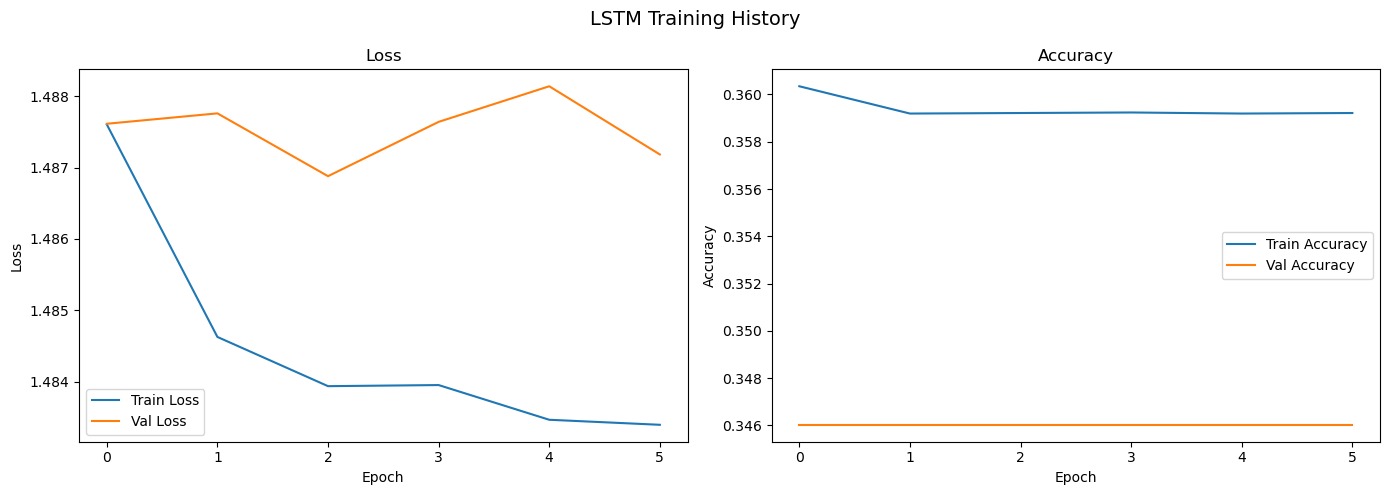

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_lstm.history['loss'], label='Train Loss')
axes[0].plot(history_lstm.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history_lstm.history['acc'], label='Train Accuracy')
axes[1].plot(history_lstm.history['val_acc'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('LSTM Training History', fontsize=14)
plt.tight_layout()
plt.show()

In [46]:
lstm_model.evaluate(X_test_emb, y_test_cat)

385/385 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - acc: 0.3587 - loss: 1.4838


[1.4837688207626343, 0.35871419310569763]

In [47]:
y_pred_lstm = encoder.inverse_transform(np.argmax(lstm_model.predict(X_test_emb), axis=1))

print("Test Macro F1 (LSTM):", f"{f1_score(y_test, y_pred_lstm, average='macro'):.4f}")

print("\nClassification Report (LSTM):")
print(classification_report(y_test, y_pred_lstm))

385/385 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step
Test Macro F1 (LSTM): 0.1056

Classification Report (LSTM):
              precision    recall  f1-score   support

           1       0.00      0.00      0.00      3531
           2       0.00      0.00      0.00      1424
           3       0.00      0.00      0.00      1377
           4       0.00      0.00      0.00      1568
           5       0.36      1.00      0.53      4419

    accuracy                           0.36     12319
   macro avg       0.07      0.20      0.11     12319
weighted avg       0.13      0.36      0.19     12319



/home/omargamalelkady/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/omargamalelkady/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/omargamalelkady/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

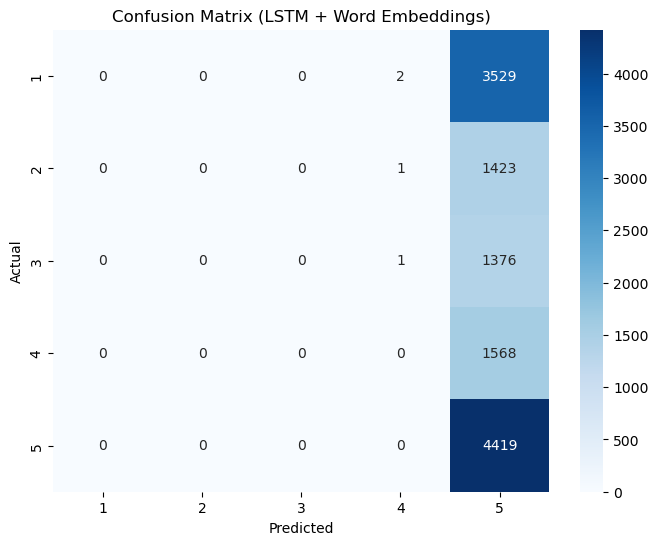

In [48]:
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (LSTM + Word Embeddings)')
plt.show()

**Observation:**
- LSTM achieved a Macro F1 of **0.1056**, the worst performing model, predicting almost exclusively one class (rating 5).
- The model collapsed — all other classes have 0.00 precision and recall, meaning it failed to learn any meaningful patterns for ratings 1–4.

#### Enhancement 5, 6 & 7: 2-Class Sentiment (Negative / Positive)

In [49]:
def map_sentiment(rating):
    if rating <= 3:
        return 'negative'
    else:
        return 'positive'

y_train_2 = y_train.map(map_sentiment)
y_test_2 = y_test.map(map_sentiment)

print("2-Class distribution (train):")
print(y_train_2.value_counts())
print('-' * 50)
print("2-Class distribution (test):")
print(y_test_2.value_counts())

2-Class distribution (train):
Rating
negative    25273
positive    23825
Name: count, dtype: int64
--------------------------------------------------
2-Class distribution (test):
Rating
negative    6332
positive    5987
Name: count, dtype: int64


In [50]:
encoder_2 = LabelEncoder()
y_train_2_encoded = encoder_2.fit_transform(y_train_2)
y_test_2_encoded = encoder_2.transform(y_test_2)

y_train_2_cat = to_categorical(y_train_2_encoded)
y_test_2_cat = to_categorical(y_test_2_encoded)

print("Classes:", encoder_2.classes_)
print("y_train_2_cat shape:", y_train_2_cat.shape)

Classes: ['negative' 'positive']
y_train_2_cat shape: (49098, 2)


#### Enhancement 5: spaCy Embeddings + LinearSVC (2-Class)

In [51]:
svc_model_2 = LinearSVC(class_weight='balanced', random_state=42)
svc_model_2.fit(X_train_vectors, y_train_2)

y_pred_emb2 = svc_model_2.predict(X_test_vectors)
print("Test Macro F1 (spaCy 2-Class):", f"{f1_score(y_test_2, y_pred_emb2, average='macro'):.4f}")

print("\nClassification Report (spaCy 2-Class):")
print(classification_report(y_test_2, y_pred_emb2))

Test Macro F1 (spaCy 2-Class): 0.7971

Classification Report (spaCy 2-Class):
              precision    recall  f1-score   support

    negative       0.78      0.84      0.81      6332
    positive       0.81      0.76      0.78      5987

    accuracy                           0.80     12319
   macro avg       0.80      0.80      0.80     12319
weighted avg       0.80      0.80      0.80     12319



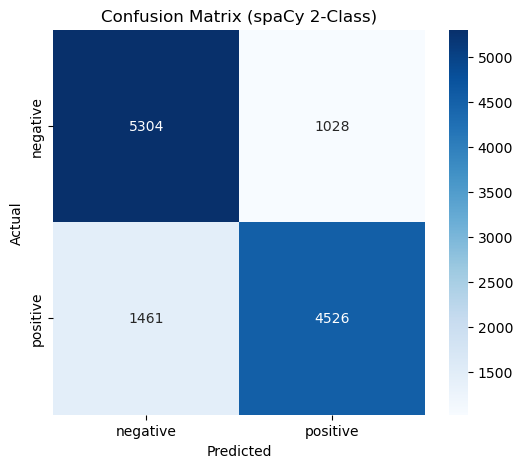

In [52]:
cm_emb2 = confusion_matrix(y_test_2, y_pred_emb2, labels=encoder_2.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_emb2, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder_2.classes_,
            yticklabels=encoder_2.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (spaCy 2-Class)')
plt.show()

**Observation:**
- spaCy Embeddings + LinearSVC (2-Class) achieved a Macro F1 of **0.7971**, a massive jump compared to the 5-class version (0.3808).
- Reducing the problem from 5 classes to 2 (negative vs positive) eliminates the confusion between adjacent ratings.
- Even the averaged word embeddings approach works much better when the task is simplified to binary sentiment classification.

#### Enhancement 6: CNN N-grams (2-Class)

In [ ]:
inputs_2 = Input((longest_input, 300))
reshaped_2 = Reshape((longest_input, 300, 1))(inputs_2)

filters = [2, 3, 4]

conv_1 = Conv2D(100, (filters[0], 300), activation='relu')(reshaped_2)
conv_2 = Conv2D(100, (filters[1], 300), activation='relu')(reshaped_2)
conv_3 = Conv2D(100, (filters[2], 300), activation='relu')(reshaped_2)

pool_1 = MaxPooling2D((longest_input - filters[0] + 1, 1), strides=(1,1))(conv_1)
pool_2 = MaxPooling2D((longest_input - filters[1] + 1, 1), strides=(1,1))(conv_2)
pool_3 = MaxPooling2D((longest_input - filters[2] + 1, 1), strides=(1,1))(conv_3)

merged = concatenate([pool_1, pool_2, pool_3], axis=1)
flat = Flatten()(merged)
dense = Dense(100, activation='relu')(flat)
dense = Dropout(0.3)(dense)
output_2 = Dense(len(encoder_2.classes_), activation='softmax')(dense)

cnn_model_2 = Model(inputs_2, output_2)
cnn_model_2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
cnn_model_2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 131, 300)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 131, 300,  │          0 │ input_layer_2[0]… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 130, 1,    │     60,100 │ reshape_1[0][0]   │
│                     │ 100)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 129, 1,    │     90,100 │ reshape_1[0][0]   │
│                     │ 100)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 1,    │    120,100 │ reshape_1[0][0]   │
│                     │ 100)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 1, 1, 100) │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 1, 1, 100) │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 1, 1, 100) │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 3, 1, 100) │          0 │ max_pooling2d_3[… │
│ (Concatenate)       │                   │            │ max_pooling2d_4[… │
│                     │                   │            │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 300)       │          0 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 100)       │     30,100 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 100)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 2)         │        202 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 300,602 (1.15 MB)

 Trainable params: 300,602 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
early_stop_cnn2 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_cnn2 = cnn_model_2.fit(X_train_emb, y_train_2_cat, epochs=30, batch_size=64,
                               validation_split=0.1, callbacks=[early_stop_cnn2])

Epoch 1/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - acc: 0.7991 - loss: 0.4410 - val_acc: 0.7870 - val_loss: 0.4553
Epoch 2/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - acc: 0.8294 - loss: 0.3894 - val_acc: 0.8077 - val_loss: 0.4175
Epoch 3/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - acc: 0.8445 - loss: 0.3564 - val_acc: 0.8255 - val_loss: 0.4082
Epoch 4/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - acc: 0.8598 - loss: 0.3266 - val_acc: 0.8234 - val_loss: 0.4204
Epoch 5/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - acc: 0.8751 - loss: 0.2920 - val_acc: 0.8246 - val_loss: 0.4470
Epoch 6/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - acc: 0.8898 - loss: 0.2578 - val_acc: 0.8240 - val_loss: 0.4798


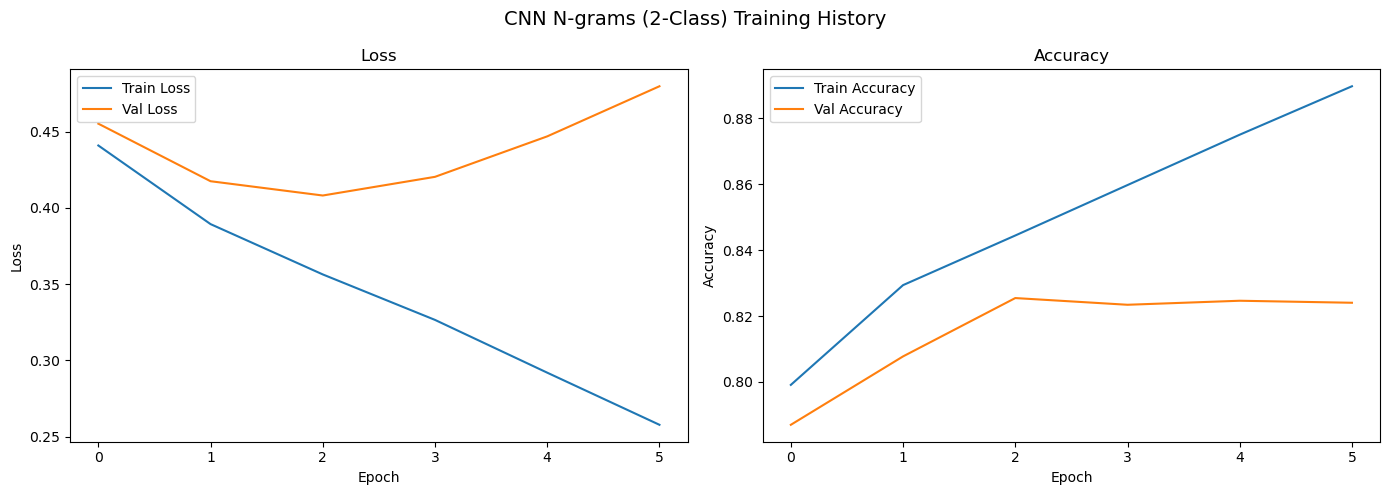

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn2.history['loss'], label='Train Loss')
axes[0].plot(history_cnn2.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_cnn2.history['acc'], label='Train Accuracy')
axes[1].plot(history_cnn2.history['val_acc'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('CNN N-grams (2-Class) Training History', fontsize=14)
plt.tight_layout()
plt.show()

In [56]:
y_pred_cnn2 = encoder_2.inverse_transform(np.argmax(cnn_model_2.predict(X_test_emb), axis=1))

print("Test Macro F1 (CNN 2-Class):", f"{f1_score(y_test_2, y_pred_cnn2, average='macro'):.4f}")

print("\nClassification Report (CNN 2-Class):")
print(classification_report(y_test_2, y_pred_cnn2))

385/385 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Test Macro F1 (CNN 2-Class): 0.8268

Classification Report (CNN 2-Class):
              precision    recall  f1-score   support

    negative       0.80      0.88      0.84      6332
    positive       0.86      0.77      0.81      5987

    accuracy                           0.83     12319
   macro avg       0.83      0.83      0.83     12319
weighted avg       0.83      0.83      0.83     12319



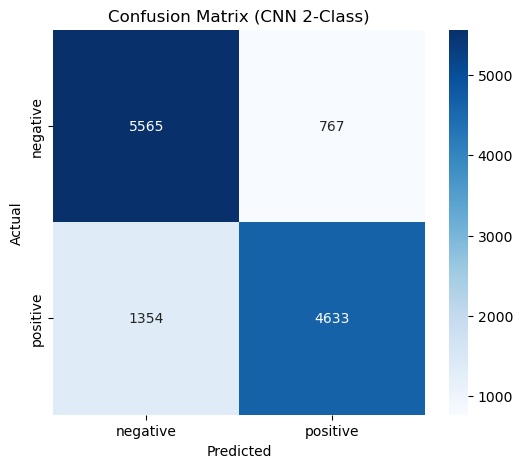

In [57]:
cm_cnn2 = confusion_matrix(y_test_2, y_pred_cnn2, labels=encoder_2.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_cnn2, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder_2.classes_,
            yticklabels=encoder_2.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (CNN 2-Class)')
plt.show()

**Observation:**
- CNN N-grams (2-Class) achieved a Macro F1 of **0.8268**, the best score so far across all models.
- The CNN benefits from the simplified binary task — its n-gram filters effectively capture local sentiment phrases.

#### Enhancement 7: LSTM (2-Class)

In [ ]:
lstm_inputs_2 = Input((longest_input, 300))
x = LSTM(128, return_sequences=True)(lstm_inputs_2)
x = Dropout(0.3)(x)
x = LSTM(64)(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
lstm_output_2 = Dense(len(encoder_2.classes_), activation='softmax')(x)

lstm_model_2 = Model(lstm_inputs_2, lstm_output_2)
lstm_model_2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
lstm_model_2.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 131, 300)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 131, 128)       │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 131, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273,346 (1.04 MB)

 Trainable params: 273,346 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
early_stop_lstm2 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_lstm2 = lstm_model_2.fit(X_train_emb, y_train_2_cat, epochs=30, batch_size=64,
                                 validation_split=0.1, callbacks=[early_stop_lstm2])

Epoch 1/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 50s 68ms/step - acc: 0.5113 - loss: 0.6930 - val_acc: 0.5200 - val_loss: 0.6924
Epoch 2/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - acc: 0.5142 - loss: 0.6929 - val_acc: 0.5200 - val_loss: 0.6924
Epoch 3/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - acc: 0.5141 - loss: 0.6927 - val_acc: 0.5200 - val_loss: 0.6924
Epoch 4/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - acc: 0.5138 - loss: 0.6929 - val_acc: 0.5200 - val_loss: 0.6925


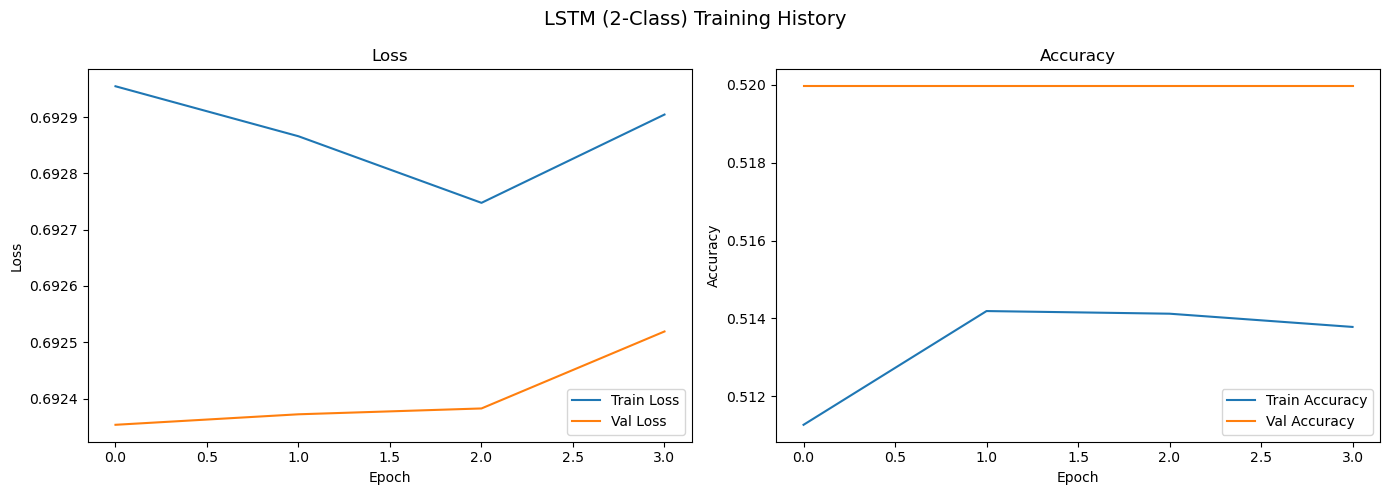

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm2.history['loss'], label='Train Loss')
axes[0].plot(history_lstm2.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_lstm2.history['acc'], label='Train Accuracy')
axes[1].plot(history_lstm2.history['val_acc'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('LSTM (2-Class) Training History', fontsize=14)
plt.tight_layout()
plt.show()

In [61]:
y_pred_lstm2 = encoder_2.inverse_transform(np.argmax(lstm_model_2.predict(X_test_emb), axis=1))

print("Test Macro F1 (LSTM 2-Class):", f"{f1_score(y_test_2, y_pred_lstm2, average='macro'):.4f}")

print("\nClassification Report (LSTM 2-Class):")
print(classification_report(y_test_2, y_pred_lstm2))

385/385 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step
Test Macro F1 (LSTM 2-Class): 0.3395

Classification Report (LSTM 2-Class):
              precision    recall  f1-score   support

    negative       0.51      1.00      0.68      6332
    positive       0.00      0.00      0.00      5987

    accuracy                           0.51     12319
   macro avg       0.26      0.50      0.34     12319
weighted avg       0.26      0.51      0.35     12319



/home/omargamalelkady/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/omargamalelkady/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/omargamalelkady/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

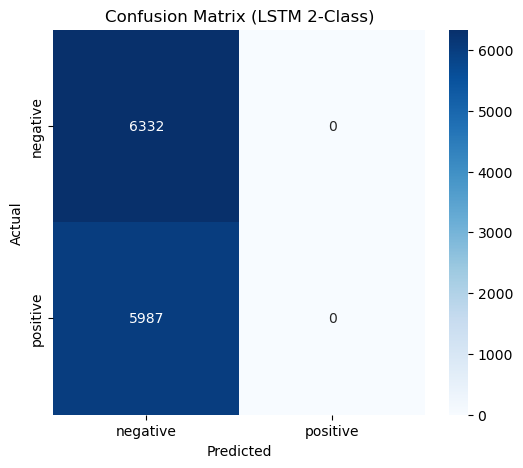

In [62]:
cm_lstm2 = confusion_matrix(y_test_2, y_pred_lstm2, labels=encoder_2.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder_2.classes_,
            yticklabels=encoder_2.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (LSTM 2-Class)')
plt.show()

**Observation:**
- LSTM (2-Class) achieved a Macro F1 of **0.3395**, predicting all samples as negative (1.00 recall on negative, 0.00 on positive).
- The model completely collapsed, same as the 5-class LSTM — it fails to learn meaningful patterns regardless of the number of classes.
- The root cause remains the excessively long padded sequences, which flood the LSTM hidden states with zero-padding noise, preventing it from retaining useful information.

### Conclusion and final results

In [ ]:
results_5 = pd.DataFrame({
    'Model': [
        'BoW + LogisticRegression (GridSearch)',
        'TF-IDF + LogisticRegression (GridSearch)',
        'spaCy Embeddings + LinearSVC',
        'CNN N-grams',
        'LSTM',
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_bow, average='macro'),
        f1_score(y_test, y_pred_tfidf, average='macro'),
        f1_score(y_test, y_pred_emb, average='macro'),
        f1_score(y_test, y_pred_cnn, average='macro'),
        f1_score(y_test, y_pred_lstm, average='macro'),
    ],
    'Task': ['5-Class'] * 5
})

results_2 = pd.DataFrame({
    'Model': [
        'spaCy Embeddings + LinearSVC (2-Class)',
        'CNN N-grams (2-Class)',
        'LSTM (2-Class)',
    ],
    'Macro F1': [
        f1_score(y_test_2, y_pred_emb2, average='macro'),
        f1_score(y_test_2, y_pred_cnn2, average='macro'),
        f1_score(y_test_2, y_pred_lstm2, average='macro'),
    ],
    'Task': ['2-Class'] * 3
})

results_all = pd.concat([results_5, results_2], ignore_index=True)
results_all['Macro F1'] = results_all['Macro F1'].round(4)
results_all = results_all.sort_values('Macro F1', ascending=False).reset_index(drop=True)
print(results_all.to_string(index=False))

                                   Model  Macro F1    Task
                   CNN N-grams (2-Class)    0.8268 2-Class
  spaCy Embeddings + LinearSVC (2-Class)    0.7971 2-Class
TF-IDF + LogisticRegression (GridSearch)    0.4922 5-Class
   BoW + LogisticRegression (GridSearch)    0.4630 5-Class
            spaCy Embeddings + LinearSVC    0.3808 5-Class
                          LSTM (2-Class)    0.3395 2-Class
                             CNN N-grams    0.3196 5-Class
                                    LSTM    0.1056 5-Class


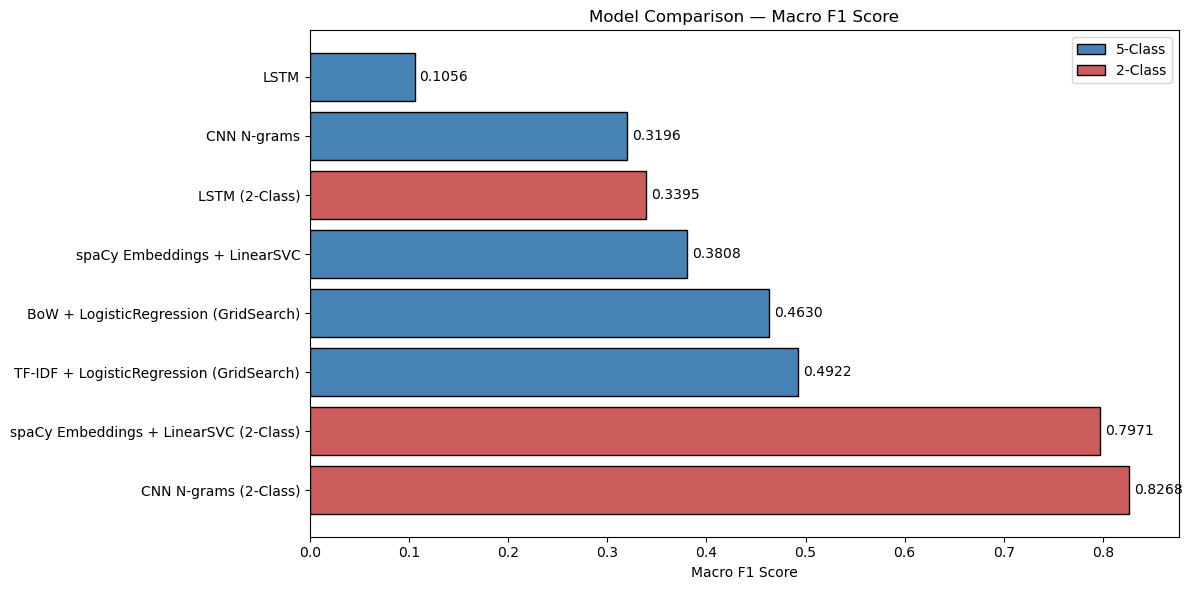

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['steelblue' if t == '5-Class' else 'indianred' for t in results_all['Task']]
bars = ax.barh(results_all['Model'], results_all['Macro F1'], color=colors, edgecolor='black')

for bar in bars:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=10)

ax.set_xlabel('Macro F1 Score')
ax.set_title('Model Comparison — Macro F1 Score')
ax.set_xlim(0, max(results_all['Macro F1']) + 0.05)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', edgecolor='black', label='5-Class'),
                   Patch(facecolor='indianred', edgecolor='black', label='2-Class')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

#### Conclusion

**5-Class Classification (Rating 1–5):**
- **TF-IDF + Logistic Regression** was the best 5-class model with a Macro F1 of **0.4922**, followed by BoW + Logistic Regression (0.4630).
- Traditional ML models (BoW, TF-IDF) outperformed deep learning models (CNN, LSTM) in the 5-class setting, as they handle sparse, high-dimensional text features well without requiring large amounts of data or careful sequence length tuning.

**2-Class Classification (Negative / Positive):**
- **CNN N-grams (2-Class)** achieved the overall best Macro F1 of **0.8268**, proving that the CNN architecture is effective when the task complexity is reduced.
- spaCy Embeddings + LinearSVC (0.7971) also performed well, showing that even averaged embeddings are powerful for binary sentiment classification.
- The LSTM (0.3395) collapsed again, confirming its sensitivity to long padded sequences.